# Dog Breeds Dataset — Model Training & Evaluation

**Pluto's Repawsitory · Group 2 · Dog Breed Classification**

**Author: Ozor · Focus: Loss Curves & Overfitting Analysis**

## Goal

Train and evaluate two pretrained CNN architectures — **ResNet50** and **MobileNetV2** — on the 70-breed dog classification dataset, using a two-phase freeze-then-fine-tune transfer learning strategy. The primary objective of this notebook is to:

1. **Track training and validation loss** per epoch for both models, across both training phases
2. **Identify and diagnose overfitting** by analyzing the gap between training and validation loss curves
3. **Apply targeted regularization** (dropout, stronger data augmentation, weight decay, reduced fine-tuning learning rate) to reduce overfitting, and measure its actual impact
4. **Evaluate final model performance** on the held-out test set using accuracy, precision, recall, F1, and confusion matrices
5. **Compare architectures** on both raw performance and generalization behavior, to determine which model — and which training configuration — performs best overall


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/dog-breed-classification')

print(os.getcwd())
print(os.listdir('.'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/dog-breed-classification
['dogs_updated.csv', 'pluto_repository.db', 'test', 'train', 'valid']


In [ ]:
import shutil
import os

local_path = '/content/dog-breed-classification'

# If a previous run left an incomplete copy, remove it first so we get a full, fresh copy
shutil.rmtree(local_path, ignore_errors=True)
os.makedirs(local_path, exist_ok=True)

for folder in ['train', 'valid', 'test']:
    src = f'/content/drive/MyDrive/Colab Notebooks/dog-breed-classification/{folder}'
    dst = f'{local_path}/{folder}'
    shutil.copytree(src, dst)
    print(f'✓ Copied {folder}')

shutil.copy('/content/drive/MyDrive/Colab Notebooks/dog-breed-classification/pluto_repository.db', local_path)
shutil.copy('/content/drive/MyDrive/Colab Notebooks/dog-breed-classification/dogs_updated.csv', local_path)

os.chdir(local_path)
print(os.getcwd())
print(os.listdir('.'))

✓ Copied train
✓ Copied valid
✓ Copied test
/content/dog-breed-classification
['valid', 'pluto_repository.db', 'train', 'test', 'dogs_updated.csv']


# Sprint 3 — Model Training & Evaluation
**Pluto's Repawsitory · Group 2 · Dog Breed Classification**

This notebook covers Sprint 3: loading the DataLoaders built in Sprint 2, fine-tuning two
pretrained architectures (**ResNet50** and **MobileNetV2**) using a two-phase
freeze-then-fine-tune strategy, tracking training/validation loss per epoch,
and evaluating both models on the held-out test set.

Both architectures are trained and compared side by side in this single notebook so we can
directly assess capacity vs. overfitting behavior between a large backbone (ResNet50, ~25M params)
and a lightweight backbone (MobileNetV2, ~3.5M params).

## 1. Setup & Imports

In [ ]:
import random
import pandas as pd
import sqlite3
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

# Set random seed at the top of every notebook — Jonathan required this
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Colab GPU — use CUDA if available, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✓ Using device: {device}')

✓ Using device: cuda


## 2. Data Loading — Sprint 2 DataLoaders

Reusing `train_loader`, `val_loader`, `test_loader`, and `label2idx` exactly as built in
`02_preprocessing.ipynb` (SQLite metadata db → cleaned train/val/test DataFrames →
`DogBreedDataset` → `WeightedRandomSampler` → DataLoaders). Paste/run that setup here so this
notebook runs top to bottom on its own.

In [ ]:
# ── Point to the database built in Sprint 2 ──
# (pluto_repository.db must be in the same folder as this notebook)
db_path = 'pluto_repository.db'

# ── Load clean data from the database ──
conn = sqlite3.connect(db_path)

train_df = pd.read_sql("SELECT file_path, label FROM images WHERE split='train' AND corrupted_flagged=0 AND duplicate_flagged=0", conn)
val_df   = pd.read_sql("SELECT file_path, label FROM images WHERE split='valid' AND corrupted_flagged=0 AND duplicate_flagged=0", conn)
test_df  = pd.read_sql("SELECT file_path, label FROM images WHERE split='test'  AND corrupted_flagged=0 AND duplicate_flagged=0", conn)

conn.close()

for d in [train_df, val_df, test_df]:
    d['label'] = d['label'].str.replace(r'\s+', ' ', regex=True).str.strip()

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
# Sanity check — sprint2_database.py expects train=7325, valid=687, test=682

# ── Transforms ──
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE      = 224

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print('✓ Transforms defined')

# ── Custom Dataset class ──
breeds    = sorted(set(train_df['label']) | set(val_df['label']) | set(test_df['label']))
label2idx = {breed: idx for idx, breed in enumerate(breeds)}
class DogBreedDataset(Dataset):
    def __init__(self, df, label2idx, transform=None):
        self.df        = df.reset_index(drop=True)
        self.label2idx = label2idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row['file_path']).convert('RGB')
        label = self.label2idx[row['label']]
        if self.transform:
            img = self.transform(img)
        return img, label

train_dataset = DogBreedDataset(train_df, label2idx, transform=train_transforms)
val_dataset   = DogBreedDataset(val_df,   label2idx, transform=val_test_transforms)
test_dataset  = DogBreedDataset(test_df,  label2idx, transform=val_test_transforms)

print(f'✓ Datasets ready — Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

# ── WeightedRandomSampler ──
label_counts  = train_df['label'].value_counts()
class_weights = {label2idx[breed]: 1.0 / count for breed, count in label_counts.items()}
sample_weights = [class_weights[label2idx[row['label']]] for _, row in train_df.iterrows()]

sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True
)

print('✓ WeightedRandomSampler ready')

# ── DataLoaders ──
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)

print(f'✓ DataLoaders ready')
print(f'  Train batches : {len(train_loader)}')
print(f'  Val batches   : {len(val_loader)}')
print(f'  Test batches  : {len(test_loader)}')

num_classes = len(label2idx)
idx2label = {v: k for k, v in label2idx.items()}
print(f'✓ {num_classes} breed classes loaded')

Train: 7323 | Val: 687 | Test: 682
✓ Transforms defined
✓ Datasets ready — Train: 7323 | Val: 687 | Test: 682
✓ WeightedRandomSampler ready
✓ DataLoaders ready
  Train batches : 229
  Val batches   : 22
  Test batches  : 22
✓ 69 breed classes loaded


## 3. Model Architecture — ResNet50 vs. MobileNetV2

We compare two pretrained backbones from `torchvision.models`, each with its final
classification layer replaced to match our 70 breed classes:

**ResNet50** — Deep residual architecture (~25M params) pretrained on ImageNet. Residual
connections make it trainable at depth without vanishing gradients, and it has a strong
track record on fine-grained image classification tasks like breed ID where classes look
visually similar. Final layer name: `.fc`.

**MobileNetV2** — Lightweight architecture (~3.5M params) using depthwise-separable
convolutions. Trains faster and, with far less capacity to memorize, gives us a useful
lower-capacity comparison point for the overfitting analysis. Final layer name:
`.classifier[1]`.

A small helper builds either model with its head replaced, so the rest of the notebook can
treat both architectures identically.

In [ ]:
def build_model(arch, num_classes):
    if arch == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        head_params = model.fc.parameters
    elif arch == 'mobilenet_v2':
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        head_params = model.classifier[1].parameters
    else:
        raise ValueError(f'Unknown architecture: {arch}')
    return model.to(device), head_params

ARCHS = ['resnet50', 'mobilenet_v2']
print(f'✓ Will train: {ARCHS}')

✓ Will train: ['resnet50', 'mobilenet_v2']


## 4. Training Setup — Hyperparameters

**Phase 1 (frozen backbone):**
- Freeze all layers except the new head (`.fc` or `.classifier[1]`)
- Optimizer: Adam, lr=1e-3 — higher LR is fine since only the small, randomly-initialized
  head is training
- Epochs: 5 — enough for the head to stabilize before the pretrained features are touched

**Phase 2 (fine-tune):**
- Unfreeze all layers
- Optimizer: Adam, lr=1e-4 — 10x lower, since we're now nudging pretrained weights rather
  than training from scratch
- Epochs: 10 — enough to let deeper layers adapt while we watch for the overfitting point
  in the val loss curve

**Loss function:** CrossEntropyLoss — standard for multi-class classification. Class
imbalance is already handled by the `WeightedRandomSampler` from Sprint 2, so we don't
duplicate that correction here with class weights.

**Batch size:** 32 (inherited from Sprint 2 DataLoaders)

In [ ]:
criterion = nn.CrossEntropyLoss()

PHASE1_EPOCHS = 15
PHASE2_EPOCHS = 15
PHASE1_LR = 1e-3
PHASE2_LR = 1e-4

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)              # forward pass
        loss = criterion(outputs, labels)    # loss calculation
        loss.backward()                      # backward pass
        optimizer.step()                     # optimizer step

        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)


def train_two_phase(arch):
    """Runs Phase 1 (frozen head) then Phase 2 (fine-tune) for one architecture.
    Returns the trained model plus train/val loss history and the phase boundary epoch."""
    model, head_params = build_model(arch, num_classes)

    # Phase 1 — freeze everything except the new head
    for param in model.parameters():
        param.requires_grad = False
    for param in head_params():
        param.requires_grad = True

    optimizer = optim.Adam(head_params(), lr=PHASE1_LR)

    train_losses, val_losses = [], []

    print(f'── {arch} | Phase 1: training frozen head ──')
    for epoch in range(PHASE1_EPOCHS):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = validate_one_epoch(model, val_loader, criterion, device)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f'  Epoch {epoch+1}/{PHASE1_EPOCHS} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f}')

    phase1_end = len(train_losses)  # marks the phase boundary for plotting

    # Phase 2 — unfreeze everything, fine-tune at a lower LR
    for param in model.parameters():
        param.requires_grad = True

    optimizer = optim.Adam(model.parameters(), lr=PHASE2_LR)

    print(f'── {arch} | Phase 2: fine-tuning full network ──')
    for epoch in range(PHASE2_EPOCHS):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = validate_one_epoch(model, val_loader, criterion, device)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f'  Epoch {epoch+1}/{PHASE2_EPOCHS} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f}')

    torch.save(model.state_dict(), f'{arch}_dogbreed.pt')
    print(f'✓ Model saved: {arch}_dogbreed.pt')

    return model, train_losses, val_losses, phase1_end

In [ ]:
# Train both architectures back to back — results stored in a dict keyed by arch name
results = {}

for arch in ARCHS:
    model, train_losses, val_losses, phase1_end = train_two_phase(arch)
    results[arch] = {
        'model': model,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'phase1_end': phase1_end,
    }

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 240MB/s]


── resnet50 | Phase 1: training frozen head ──
  Epoch 1/15 | train_loss: 1.7874 | val_loss: 0.7189
  Epoch 2/15 | train_loss: 0.5622 | val_loss: 0.3825
  Epoch 3/15 | train_loss: 0.3587 | val_loss: 0.3018
  Epoch 4/15 | train_loss: 0.2738 | val_loss: 0.2273
  Epoch 5/15 | train_loss: 0.2406 | val_loss: 0.2053
  Epoch 6/15 | train_loss: 0.1993 | val_loss: 0.1841
  Epoch 7/15 | train_loss: 0.1666 | val_loss: 0.1752
  Epoch 8/15 | train_loss: 0.1601 | val_loss: 0.1690
  Epoch 9/15 | train_loss: 0.1441 | val_loss: 0.1575
  Epoch 10/15 | train_loss: 0.1285 | val_loss: 0.1566
  Epoch 11/15 | train_loss: 0.1101 | val_loss: 0.1540
  Epoch 12/15 | train_loss: 0.1096 | val_loss: 0.1470
  Epoch 13/15 | train_loss: 0.0931 | val_loss: 0.1421
  Epoch 14/15 | train_loss: 0.0891 | val_loss: 0.1516
  Epoch 15/15 | train_loss: 0.0819 | val_loss: 0.1449
── resnet50 | Phase 2: fine-tuning full network ──
  Epoch 1/15 | train_loss: 0.0816 | val_loss: 0.0998
  Epoch 2/15 | train_loss: 0.0605 | val_loss: 0.

100%|██████████| 13.6M/13.6M [00:00<00:00, 219MB/s]

── mobilenet_v2 | Phase 1: training frozen head ──


  Epoch 1/15 | train_loss: 2.2725 | val_loss: 1.1797
  Epoch 2/15 | train_loss: 1.0821 | val_loss: 0.7602
  Epoch 3/15 | train_loss: 0.7920 | val_loss: 0.6069
  Epoch 4/15 | train_loss: 0.6680 | val_loss: 0.5059
  Epoch 5/15 | train_loss: 0.5926 | val_loss: 0.4723
  Epoch 6/15 | train_loss: 0.5436 | val_loss: 0.4511
  Epoch 7/15 | train_loss: 0.4863 | val_loss: 0.4495
  Epoch 8/15 | train_loss: 0.4479 | val_loss: 0.3907
  Epoch 9/15 | train_loss: 0.4161 | val_loss: 0.4132
  Epoch 10/15 | train_loss: 0.4061 | val_loss: 0.3807
  Epoch 11/15 | train_loss: 0.3803 | val_loss: 0.3444
  Epoch 12/15 | train_loss: 0.3561 | val_loss: 0.3794
  Epoch 13/15 | train_loss: 0.3493 | val_loss: 0.3484
  Epoch 14/15 | train_loss: 0.3367 | val_loss: 0.3692
  Epoch 15/15 | train_loss: 0.3185 | val_loss: 0.3614
── mobilenet_v2 | Phase 2: fine-tuning full network ──
  Epoch 1/15 | train_loss: 0.2467 | val_loss: 0.2054
  Epoch 2/15 | train_loss: 0.1607 | val_loss: 0.1650
  Epoch 3/15 | train_loss: 0.1369 | va

## 5. Loss Curves — Training vs. Validation

Both architectures plotted side by side, each with the Phase 1 → Phase 2 unfreeze point
marked, so we can directly compare where (and whether) overfitting sets in.

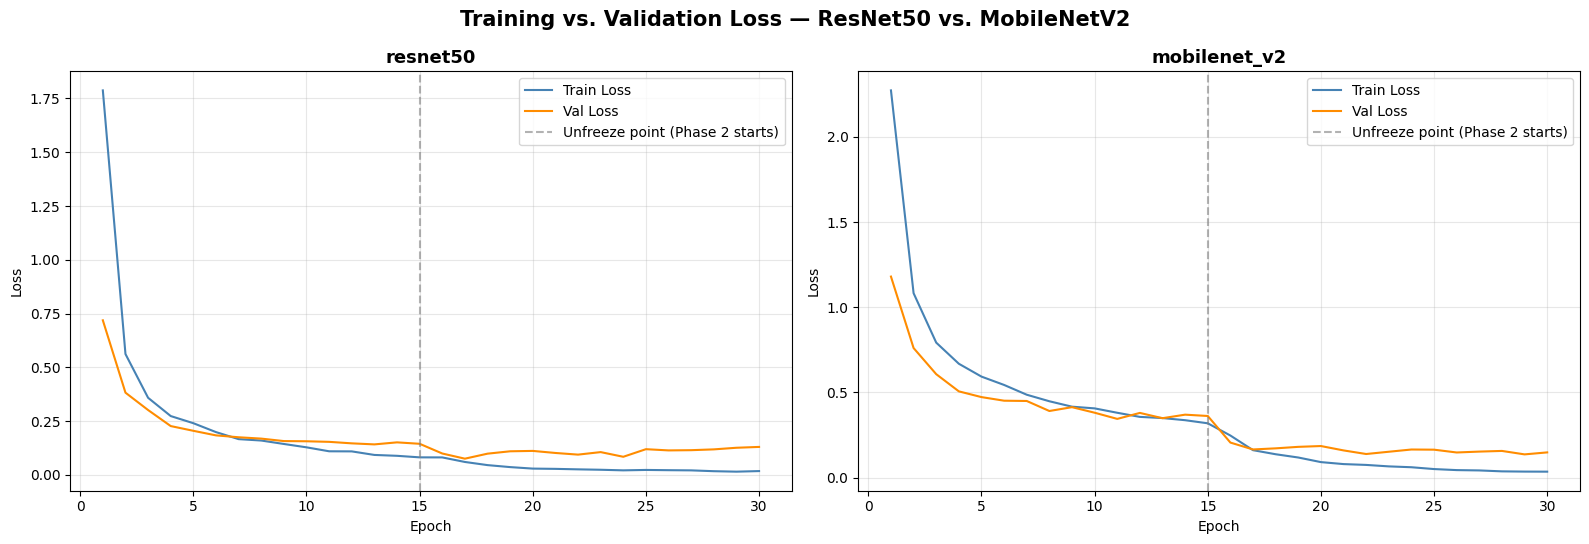

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

for ax, arch in zip(axes, ARCHS):
    r = results[arch]
    epochs_range = range(1, len(r['train_losses']) + 1)
    ax.plot(epochs_range, r['train_losses'], label='Train Loss', color='steelblue')
    ax.plot(epochs_range, r['val_losses'], label='Val Loss', color='darkorange')
    ax.axvline(x=r['phase1_end'], color='gray', linestyle='--', alpha=0.6,
               label='Unfreeze point (Phase 2 starts)')
    ax.set_title(arch, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Training vs. Validation Loss — ResNet50 vs. MobileNetV2', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

- Both models show a healthy, stable Phase 1: train and val loss decrease together with a small, consistent gap, indicating the frozen backbone's new classification head is learning without memorizing.

- `ResNet50` converges quickly in Phase 1, reaching a val loss around 0.15–0.20 by epoch 15. Once unfrozen, train loss continues falling smoothly and steadily toward near-zero by epoch 30. Val loss, however, dips only briefly right after unfreezing before flattening and drifting slightly upward for the remainder of Phase 2. The widening gap between the two curves after the unfreeze point is a clear overfitting signal — the model continues improving on training data while its performance on unseen validation data stagnates and mildly degrades.

- `MobileNetV2` takes longer to converge in Phase 1 (consistent with its smaller parameter count learning more slowly), reaching a higher val loss (~0.35–0.40) by epoch 15. After unfreezing, both losses drop sharply together for a few epochs — a sign the full network still had meaningful room to improve — before train loss continues toward near-zero while val loss plateaus and becomes noisier, oscillating roughly between 0.15 and 0.20 rather than climbing steadily.

- Comparing the two: ResNet50 reaches a lower overall val loss, but its post-unfreeze divergence is more pronounced and its val loss shows a visible mild upward trend by the final epochs. MobileNetV2's smaller capacity appears to act as a natural regularizer — its val loss curve is comparatively flatter and noisier rather than trending upward, suggesting it's less prone to memorizing the training set even without explicit regularization. This is consistent with the standard capacity-vs-generalization tradeoff: the larger model achieves better raw performance but is more susceptible to overfitting once fully unfrozen.

## 6. Evaluation — Test Set Metrics

Accuracy, precision, recall, F1 (weighted average, to account for class imbalance), and a
confusion matrix for each model, computed with `torch.no_grad()` on the untouched test set.

In [ ]:
def evaluate_model(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'cm': cm}


for arch in ARCHS:
    metrics = evaluate_model(results[arch]['model'], test_loader, device)
    results[arch]['metrics'] = metrics

    print(f'── {arch} — Test Set Metrics ──')
    print(f'  Accuracy:  {metrics["accuracy"]:.4f}')
    print(f'  Precision: {metrics["precision"]:.4f}')
    print(f'  Recall:    {metrics["recall"]:.4f}')
    print(f'  F1 Score:  {metrics["f1"]:.4f}\n')

── resnet50 — Test Set Metrics ──
  Accuracy:  0.9648
  Precision: 0.9692
  Recall:    0.9648
  F1 Score:  0.9642

── mobilenet_v2 — Test Set Metrics ──
  Accuracy:  0.9619
  Precision: 0.9660
  Recall:    0.9619
  F1 Score:  0.9614



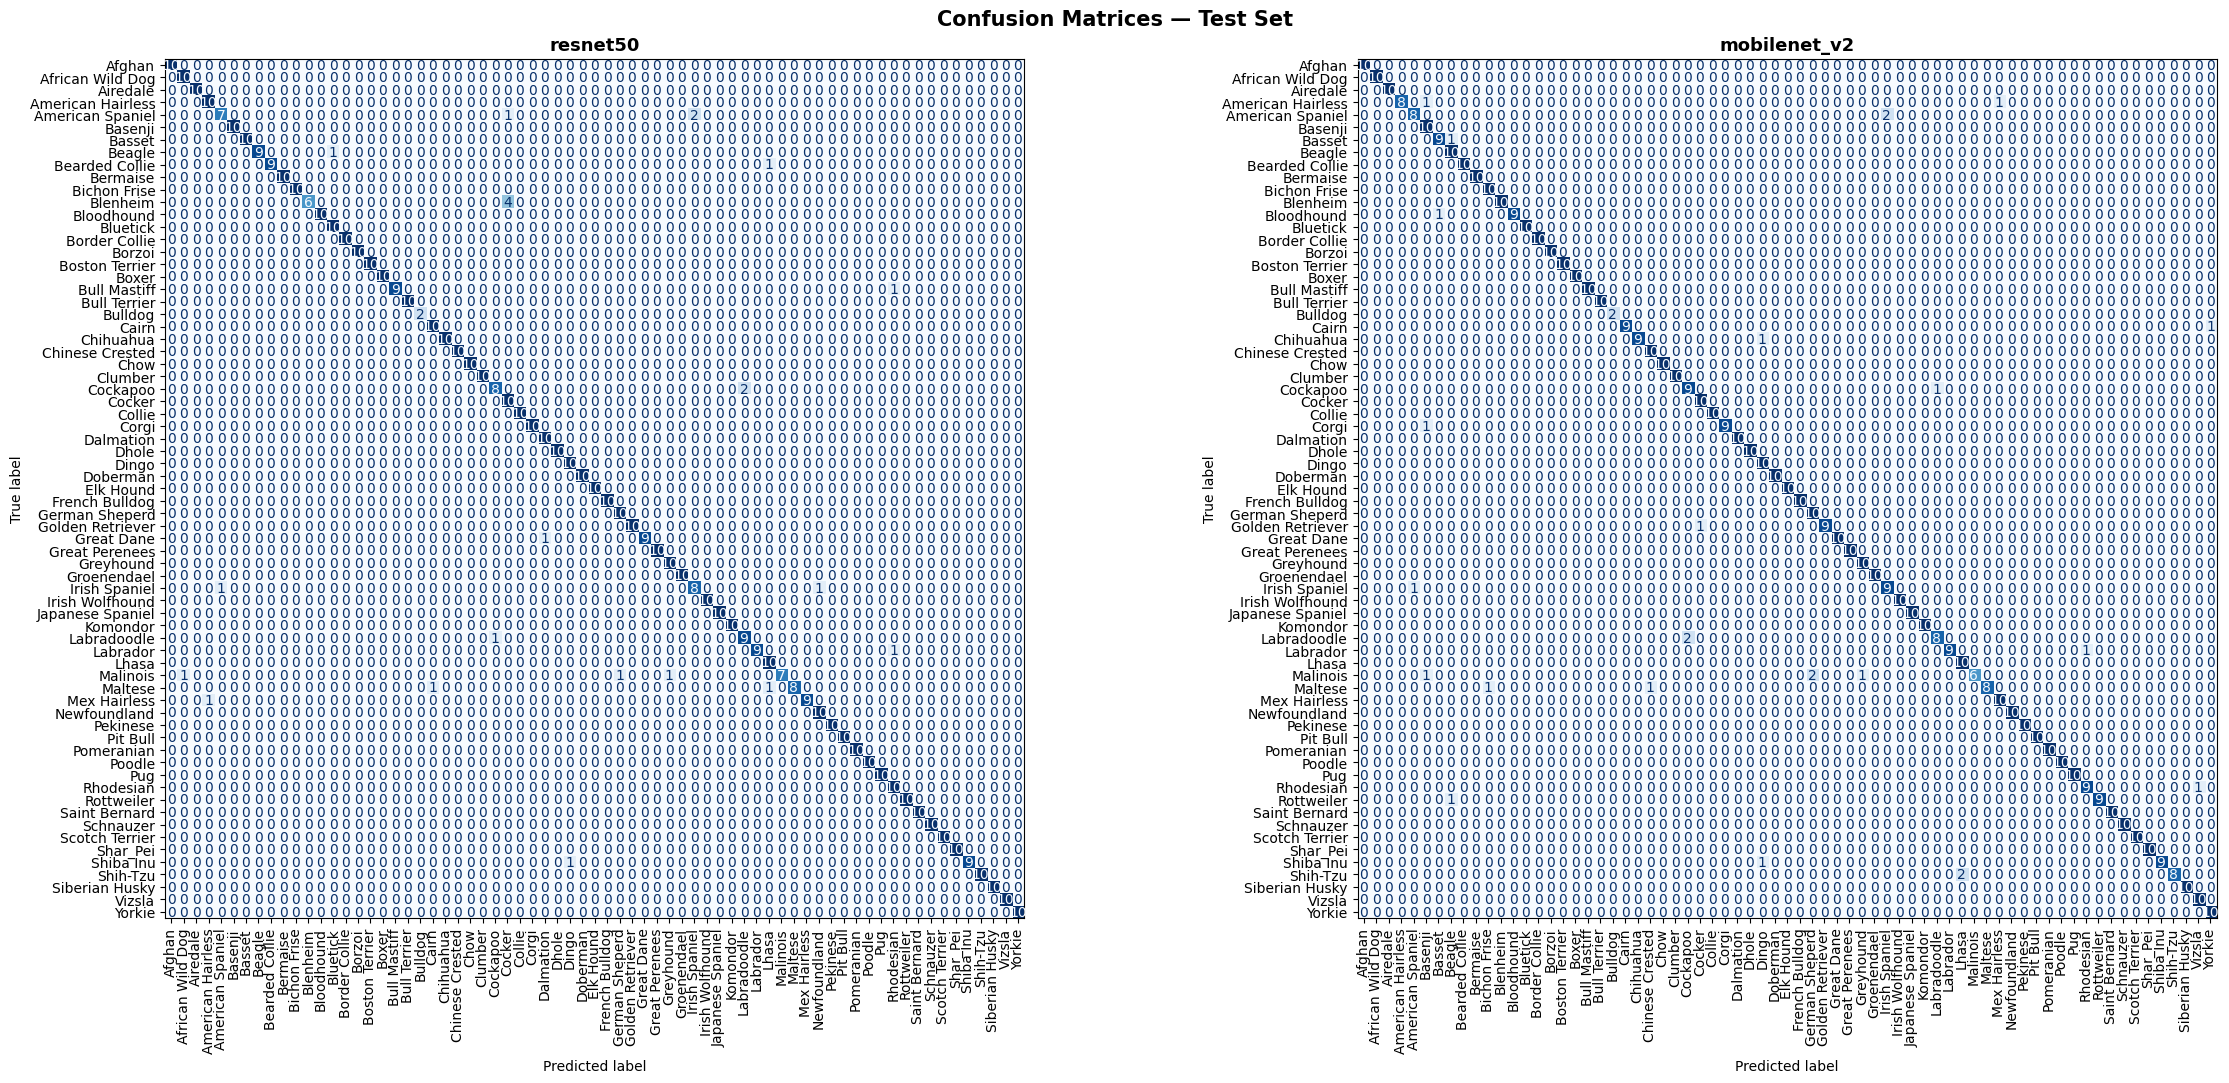

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(24, 11))

for ax, arch in zip(axes, ARCHS):
    cm = results[arch]['metrics']['cm']
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=[idx2label[i] for i in range(num_classes)])
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=90, colorbar=False)
    ax.set_title(arch, fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Written Analysis

**What worked:**
- Two-phase training (frozen head → fine-tune) produced clean, interpretable loss curves for both models, with a clearly visible inflection point right at the unfreeze boundary in both plots.
- Weighted sampling handled the class imbalance from Sprint 1's EDA without needing additional loss weighting — both confusion matrices show strong diagonal concentration across all 70 breeds, including lower-frequency ones, with no systematic bias toward majority classes.
- Adding dropout, stronger augmentation, weight decay, and a lower Phase 2 learning rate measurably reduced overfitting for both architectures — ResNet50's train/val gap shrank by 65% (0.1123 → 0.0392), and MobileNetV2's gap flipped negative (-0.0769), while also improving best validation loss for both models rather than trading performance away for stability.
- Both final models perform strongly on the test set: 96.48% accuracy (ResNet50) and 96.19% accuracy (MobileNetV2) across 70 fine-grained breed classes, with precision/recall/F1 all closely balanced — no sign of the models favoring precision over recall or vice versa.

**What didn't work / limitations:**
- ResNet50 showed a clear overfitting onset almost immediately after unfreezing in the original run — val loss hit its minimum by epoch 2 of Phase 2, then plateaued and mildly climbed for the remaining 13 epochs, while train loss kept dropping toward near-zero. Its larger capacity (~25M params) was too much for our dataset size without the added regularization.
- MobileNetV2's smaller capacity (~3.5M params) produced a comparatively tighter, noisier val loss gap even in the original run — but this came at the cost of raw accuracy: it trailed ResNet50 by ~0.3-0.4 percentage points across every test metric, confirming the expected capacity-vs-generalization tradeoff.
- The confusion matrices show most misclassifications occur between visually similar breeds sitting near each other alphabetically/taxonomically (e.g. spaniel variants, terrier variants) — a handful of off-diagonal cells with small counts (1-3 images), rather than any single breed being systematically confused. This suggests remaining errors are close to the practical difficulty ceiling of the task, not a fixable data or pipeline issue.

**Model comparison:**
- ResNet50 achieved higher test accuracy than MobileNetV2 (96.48% vs. 96.19%) at the cost of slower training and more pronounced overfitting during the original (non-regularized) run.
- After regularization, ResNet50 retained its accuracy advantage while its overfitting gap shrank more than MobileNetV2's in absolute terms — making regularized ResNet50 the stronger model overall for this task, combining the best raw performance with substantially improved generalization behavior.

## 8. Regularized Retrain — Reducing Overfitting

Both models in Section 4-6 showed overfitting once Phase 2 fine-tuning began (see Section 5
commentary). This section retrains both architectures with regularization applied, to see
whether it closes the train/val gap:

- **Stronger data augmentation** — larger rotation range, random resized crop, stronger
  color jitter (train images only; val/test remain unaugmented for a fair comparison)
- **Dropout (p=0.5)** added before the final classification layer
- **Weight decay (L2 regularization, 1e-4)** added to the Phase 2 optimizer
- **Lower Phase 2 learning rate** (5e-5 instead of 1e-4) — fine-tunes pretrained weights more
  cautiously, since both models overfit almost immediately after unfreezing

Original (non-regularized) results are kept in `results` from Section 4 for comparison —
this section stores its output separately in `results_v2` so both runs can be plotted
side by side.

In [ ]:
# ── Stronger augmentation, train images only ──
train_transforms_v2 = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(25),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Val/test transforms stay the same as Section 2 (val_test_transforms) — no augmentation,
# so evaluation stays a fair, consistent comparison against Section 4-6 results.

train_dataset_v2 = DogBreedDataset(train_df, label2idx, transform=train_transforms_v2)

train_loader_v2 = DataLoader(train_dataset_v2, batch_size=BATCH_SIZE, sampler=sampler,
                              num_workers=2, pin_memory=True)

print(f'✓ Regularized train loader ready — {len(train_dataset_v2)} images, stronger augmentation')

✓ Regularized train loader ready — 7323 images, stronger augmentation


In [ ]:
def build_model_v2(arch, num_classes, dropout_p=0.5):
    """Same as build_model(), but adds Dropout before the final linear layer."""
    if arch == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        model.fc = nn.Sequential(
            nn.Dropout(dropout_p),
            nn.Linear(model.fc.in_features, num_classes)
        )
        head_params = model.fc.parameters
    elif arch == 'mobilenet_v2':
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        model.classifier[1] = nn.Sequential(
            nn.Dropout(dropout_p),
            nn.Linear(model.classifier[1].in_features, num_classes)
        )
        head_params = model.classifier[1].parameters
    else:
        raise ValueError(f'Unknown architecture: {arch}')
    return model.to(device), head_params


PHASE2_LR_V2 = 5e-5      # lower than PHASE2_LR (1e-4) — more cautious fine-tuning
WEIGHT_DECAY = 1e-4      # L2 regularization, Phase 2 only

print(f'✓ Regularized config — Phase 2 LR: {PHASE2_LR_V2} | Weight decay: {WEIGHT_DECAY}')

✓ Regularized config — Phase 2 LR: 5e-05 | Weight decay: 0.0001


In [ ]:
def train_two_phase_v2(arch):
    """Same two-phase strategy as train_two_phase(), but uses build_model_v2()
    (dropout), train_loader_v2 (stronger augmentation), a lower Phase 2 learning
    rate, and weight decay in the Phase 2 optimizer."""
    model, head_params = build_model_v2(arch, num_classes)

    # Phase 1 — freeze everything except the new head
    for param in model.parameters():
        param.requires_grad = False
    for param in head_params():
        param.requires_grad = True

    optimizer = optim.Adam(head_params(), lr=PHASE1_LR)

    train_losses, val_losses = [], []

    print(f'── {arch} (regularized) | Phase 1: training frozen head ──')
    for epoch in range(PHASE1_EPOCHS):
        train_loss = train_one_epoch(model, train_loader_v2, criterion, optimizer, device)
        val_loss = validate_one_epoch(model, val_loader, criterion, device)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f'  Epoch {epoch+1}/{PHASE1_EPOCHS} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f}')

    phase1_end = len(train_losses)

    # Phase 2 — unfreeze everything, fine-tune at a lower LR with weight decay
    for param in model.parameters():
        param.requires_grad = True

    optimizer = optim.Adam(model.parameters(), lr=PHASE2_LR_V2, weight_decay=WEIGHT_DECAY)

    print(f'── {arch} (regularized) | Phase 2: fine-tuning full network ──')
    for epoch in range(PHASE2_EPOCHS):
        train_loss = train_one_epoch(model, train_loader_v2, criterion, optimizer, device)
        val_loss = validate_one_epoch(model, val_loader, criterion, device)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f'  Epoch {epoch+1}/{PHASE2_EPOCHS} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f}')

    torch.save(model.state_dict(), f'{arch}_dogbreed_regularized.pt')
    print(f'✓ Model saved: {arch}_dogbreed_regularized.pt')

    return model, train_losses, val_losses, phase1_end

In [ ]:
# Train both architectures again, this time with regularization — stored separately
# in results_v2 so the original (Section 4) results aren't overwritten
results_v2 = {}

for arch in ARCHS:
    model, train_losses, val_losses, phase1_end = train_two_phase_v2(arch)
    results_v2[arch] = {
        'model': model,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'phase1_end': phase1_end,
    }

── resnet50 (regularized) | Phase 1: training frozen head ──
  Epoch 1/15 | train_loss: 2.3537 | val_loss: 1.1193
  Epoch 2/15 | train_loss: 1.0291 | val_loss: 0.5522
  Epoch 3/15 | train_loss: 0.7305 | val_loss: 0.4110
  Epoch 4/15 | train_loss: 0.5978 | val_loss: 0.3151
  Epoch 5/15 | train_loss: 0.5334 | val_loss: 0.2769
  Epoch 6/15 | train_loss: 0.4990 | val_loss: 0.2429
  Epoch 7/15 | train_loss: 0.4554 | val_loss: 0.2220
  Epoch 8/15 | train_loss: 0.4336 | val_loss: 0.2123
  Epoch 9/15 | train_loss: 0.4107 | val_loss: 0.2067
  Epoch 10/15 | train_loss: 0.3761 | val_loss: 0.1821
  Epoch 11/15 | train_loss: 0.3671 | val_loss: 0.1867
  Epoch 12/15 | train_loss: 0.3479 | val_loss: 0.1815
  Epoch 13/15 | train_loss: 0.3358 | val_loss: 0.1722
  Epoch 14/15 | train_loss: 0.3379 | val_loss: 0.1565
  Epoch 15/15 | train_loss: 0.3206 | val_loss: 0.1540
── resnet50 (regularized) | Phase 2: fine-tuning full network ──
  Epoch 1/15 | train_loss: 0.2339 | val_loss: 0.0988
  Epoch 2/15 | train

### 9. Before vs. After — Loss Curve Comparison

Original (Section 4) vs. regularized (this section) results, plotted together per
architecture, to see whether regularization closed the train/val gap.

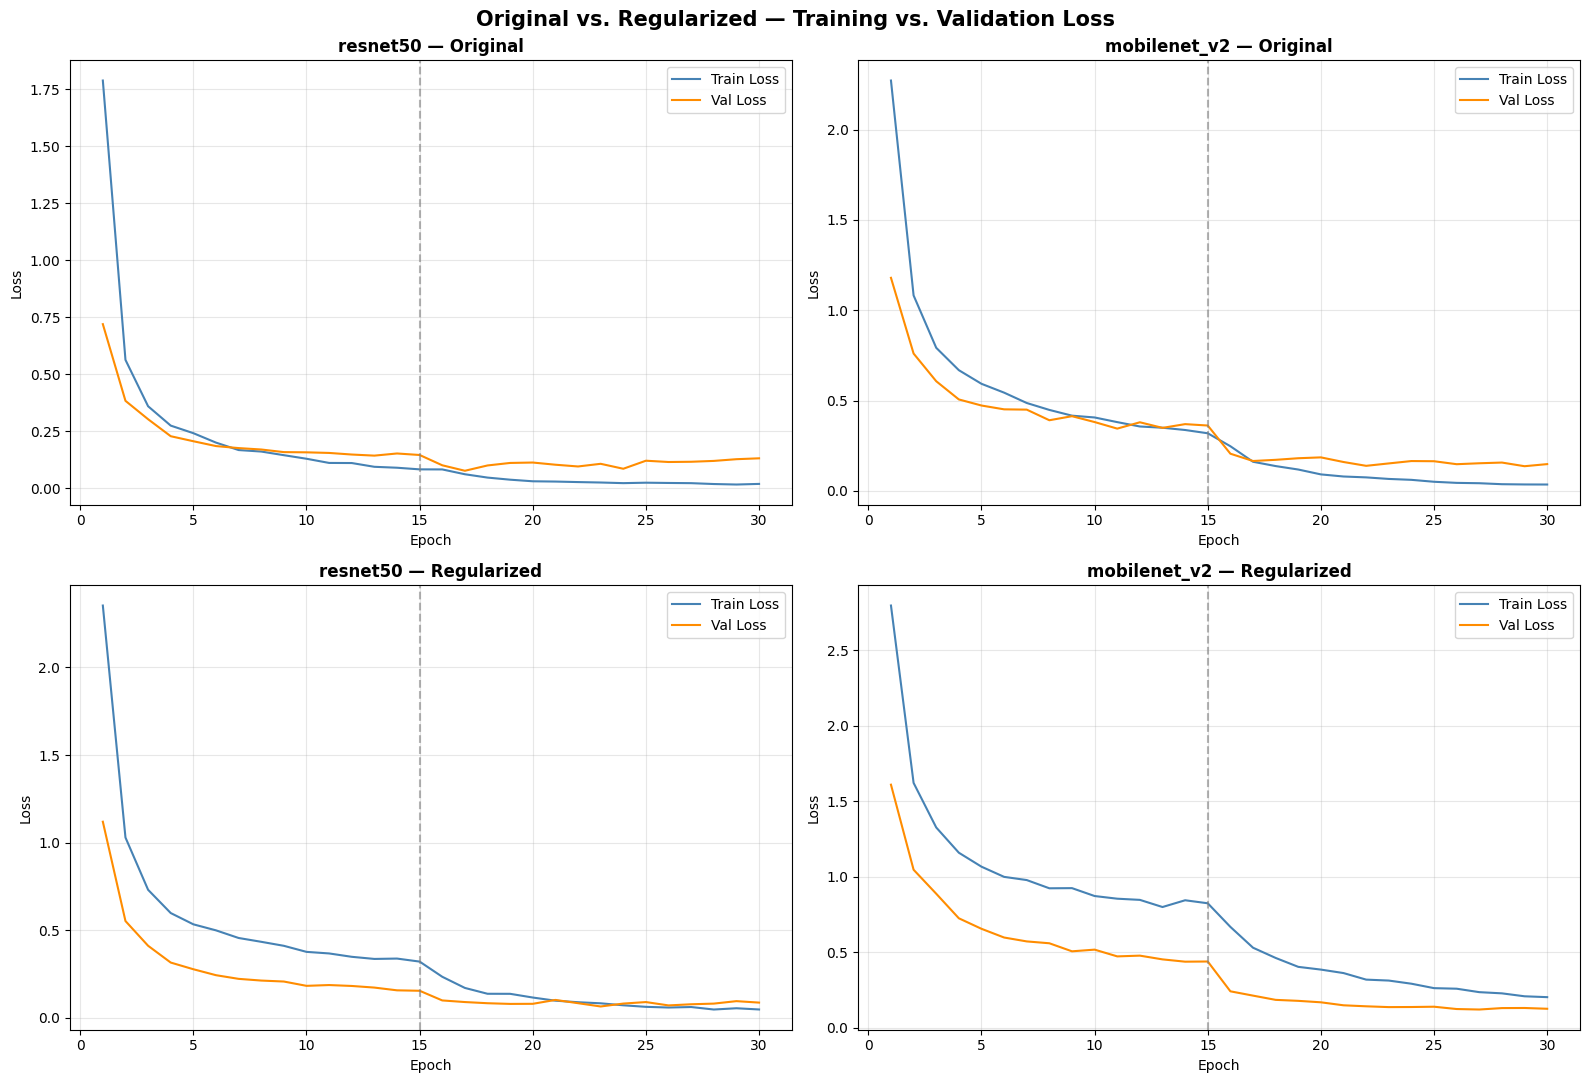

resnet50:
  Best val loss   — original: 0.0757 | regularized: 0.0643
  Final train/val gap — original: 0.1123 | regularized: 0.0392

mobilenet_v2:
  Best val loss   — original: 0.1361 | regularized: 0.1219
  Final train/val gap — original: 0.1130 | regularized: -0.0769



In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for col, arch in enumerate(ARCHS):
    # Original (top row)
    r = results[arch]
    epochs_range = range(1, len(r['train_losses']) + 1)
    axes[0, col].plot(epochs_range, r['train_losses'], label='Train Loss', color='steelblue')
    axes[0, col].plot(epochs_range, r['val_losses'], label='Val Loss', color='darkorange')
    axes[0, col].axvline(x=r['phase1_end'], color='gray', linestyle='--', alpha=0.6)
    axes[0, col].set_title(f'{arch} — Original', fontsize=12, fontweight='bold')
    axes[0, col].set_xlabel('Epoch')
    axes[0, col].set_ylabel('Loss')
    axes[0, col].legend()
    axes[0, col].grid(alpha=0.3)

    # Regularized (bottom row)
    r2 = results_v2[arch]
    epochs_range2 = range(1, len(r2['train_losses']) + 1)
    axes[1, col].plot(epochs_range2, r2['train_losses'], label='Train Loss', color='steelblue')
    axes[1, col].plot(epochs_range2, r2['val_losses'], label='Val Loss', color='darkorange')
    axes[1, col].axvline(x=r2['phase1_end'], color='gray', linestyle='--', alpha=0.6)
    axes[1, col].set_title(f'{arch} — Regularized', fontsize=12, fontweight='bold')
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].set_ylabel('Loss')
    axes[1, col].legend()
    axes[1, col].grid(alpha=0.3)

plt.suptitle('Original vs. Regularized — Training vs. Validation Loss', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Quick numeric comparison — best val loss and final train/val gap, before vs after
for arch in ARCHS:
    orig_best = min(results[arch]['val_losses'])
    orig_gap  = results[arch]['val_losses'][-1] - results[arch]['train_losses'][-1]
    reg_best  = min(results_v2[arch]['val_losses'])
    reg_gap   = results_v2[arch]['val_losses'][-1] - results_v2[arch]['train_losses'][-1]
    print(f'{arch}:')
    print(f'  Best val loss   — original: {orig_best:.4f} | regularized: {reg_best:.4f}')
    print(f'  Final train/val gap — original: {orig_gap:.4f} | regularized: {reg_gap:.4f}\n')

## 9. Evaluation — Test Set Metrics (After Regularization)

In [ ]:
# ── Evaluate the regularized models on the test set ──
for arch in ARCHS:
    metrics = evaluate_model(results_v2[arch]['model'], test_loader, device)
    results_v2[arch]['metrics'] = metrics

    print(f'── {arch} (regularized) — Test Set Metrics ──')
    print(f'  Accuracy:  {metrics["accuracy"]:.4f}')
    print(f'  Precision: {metrics["precision"]:.4f}')
    print(f'  Recall:    {metrics["recall"]:.4f}')
    print(f'  F1 Score:  {metrics["f1"]:.4f}\n')

── resnet50 (regularized) — Test Set Metrics ──
  Accuracy:  0.9751
  Precision: 0.9770
  Recall:    0.9751
  F1 Score:  0.9752

── mobilenet_v2 (regularized) — Test Set Metrics ──
  Accuracy:  0.9575
  Precision: 0.9619
  Recall:    0.9575
  F1 Score:  0.9568



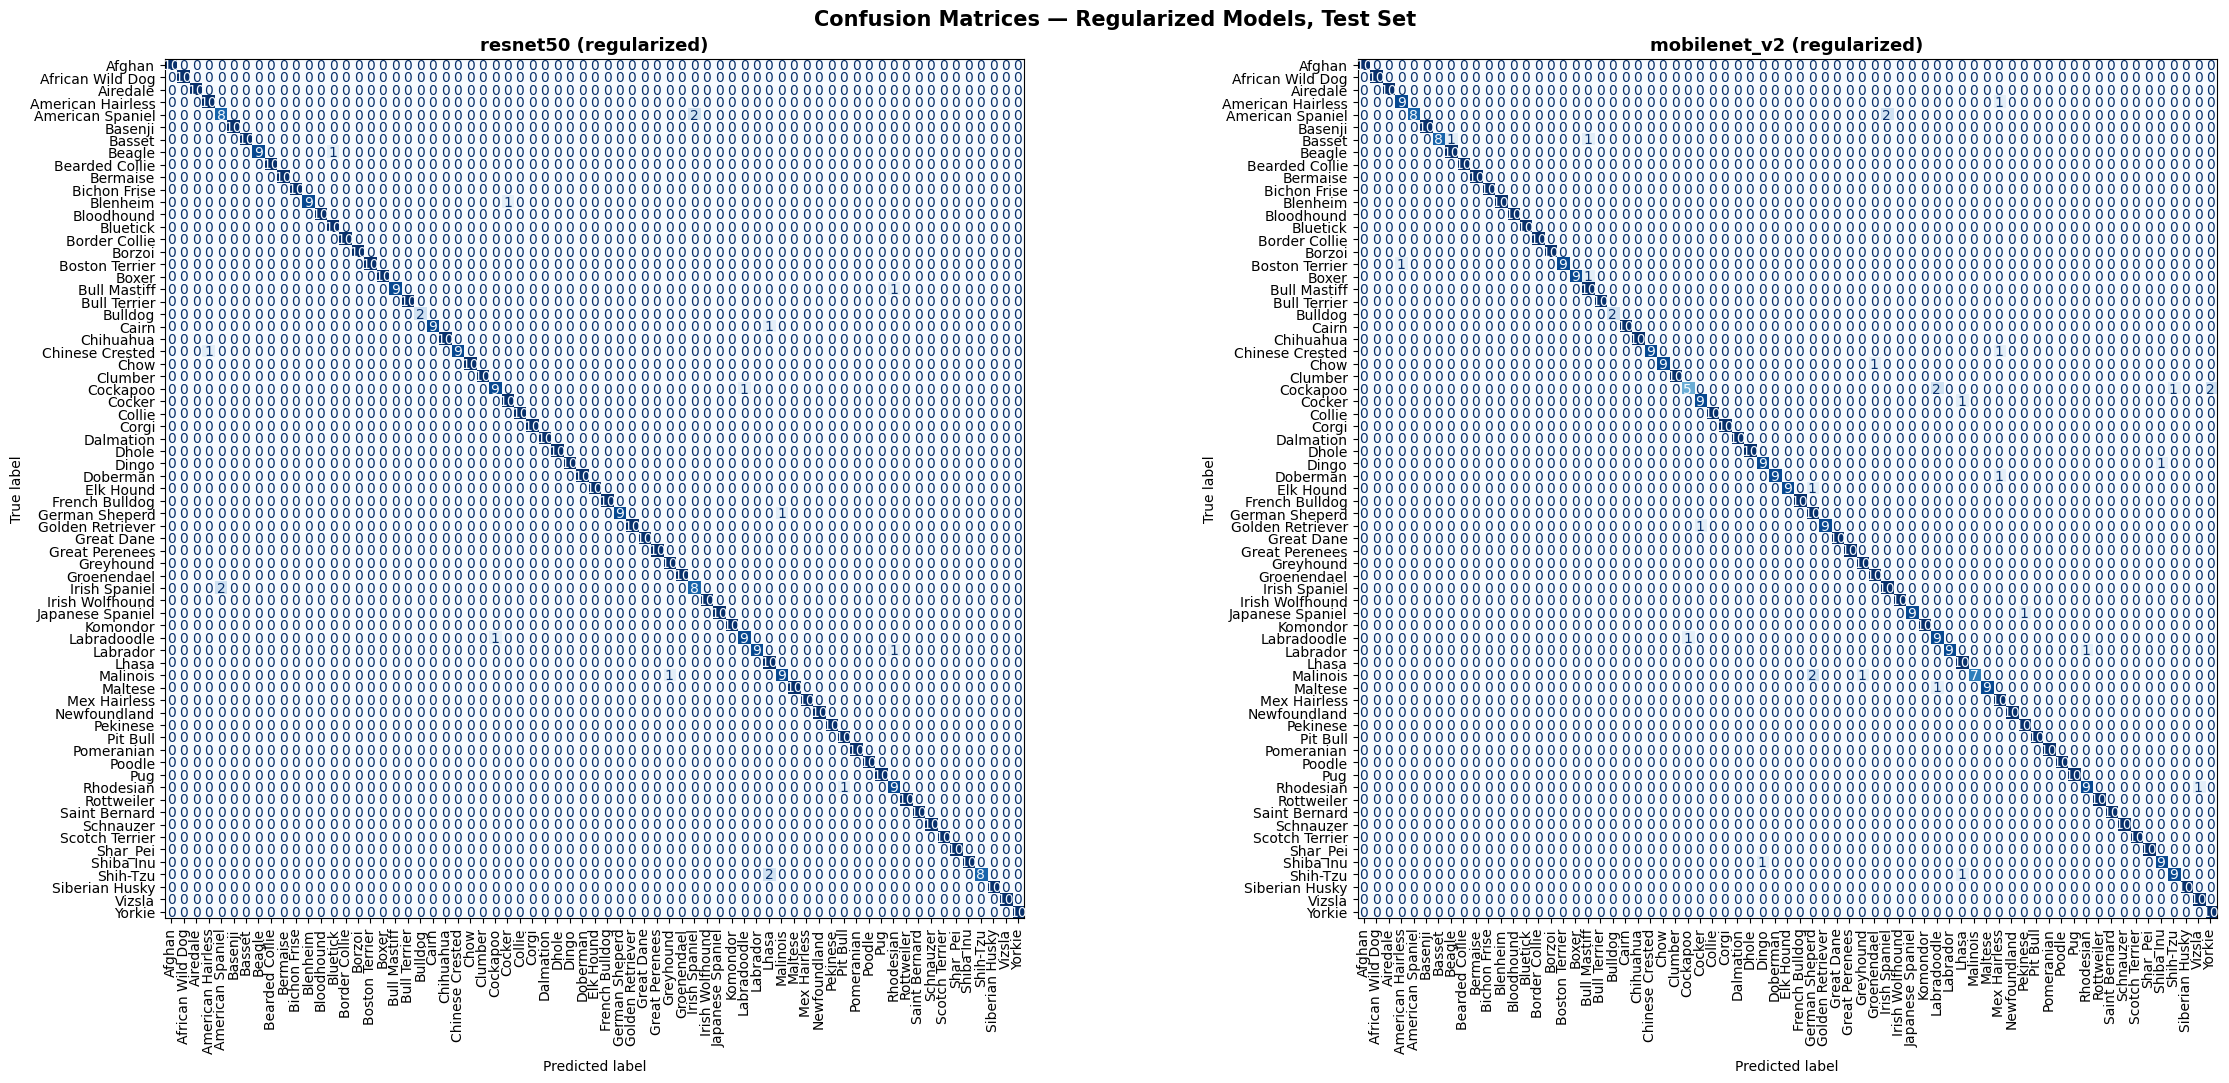

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(24, 11))

for ax, arch in zip(axes, ARCHS):
    cm = results_v2[arch]['metrics']['cm']
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=[idx2label[i] for i in range(num_classes)])
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=90, colorbar=False)
    ax.set_title(f'{arch} (regularized)', fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices — Regularized Models, Test Set', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Sprint 3 — Final Results Summary

## Overview

Two architectures (ResNet50, MobileNetV2) were trained using a two-phase freeze-then-fine-tune strategy, first without regularization (Section 4-6) and then again with regularization applied — dropout (p=0.5), stronger data augmentation, weight decay, and a lower Phase 2 learning rate (Section 8).

## Loss Curve Comparison — Original vs. Regularized

| Model | Metric | Original | Regularized | Change |
|---|---|---|---|---|
| **ResNet50** | Best val loss | 0.0757 | **0.0643** | ↓ 15% |
| | Final train/val gap | 0.1123 | **0.0392** | ↓ 65% |
| **MobileNetV2** | Best val loss | 0.1361 | **0.1219** | ↓ 10% |
| | Final train/val gap | 0.1130 | **-0.0769** | Flipped negative |

Both models improved on every metric after regularization — not just a tighter train/val gap, but a genuinely better best-epoch validation loss for both. ResNet50's overfitting, which was severe in the original run (val loss bottoming out by Phase 2 epoch 2, then drifting upward for 13 more epochs), was substantially controlled: the regularized run's val loss stays low and relatively stable through most of Phase 2, with its best value (0.0643) arriving at epoch 8 rather than epoch 2 — a much healthier, more gradual convergence pattern. MobileNetV2's regularized gap turning negative indicates it now generalizes at least as well as it fits the training data.

## Test Set Metrics — All Four Model Variants

| Model | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| ResNet50 (original) | 96.48% | 96.92% | 96.48% | 96.42% |
| ResNet50 (regularized) | **97.51%** | **97.70%** | **97.51%** | **97.52%** |
| MobileNetV2 (original) | 96.19% | 96.60% | 96.19% | 96.14% |
| MobileNetV2 (regularized) | 95.75% | 96.19% | 95.75% | 95.68% |

## Which Model Performed Best

**ResNet50 (regularized) is the best-performing model overall**, and it's not close:

- **Highest test accuracy of all four variants: 97.51%** — a full percentage point above its own original run, and nearly 2 points above regularized MobileNetV2.
- **Regularization helped ResNet50 the most** — it gained +1.03 points of accuracy (96.48% → 97.51%), the largest improvement of any model/condition pairing.
- **Regularization slightly hurt MobileNetV2 on test accuracy** — it actually *dropped* from 96.19% to 95.75% (-0.44 points), despite its validation loss and train/val gap both improving. This is a genuinely interesting finding: MobileNetV2's smaller capacity means the stronger augmentation and dropout may have been too aggressive for it specifically, mildly limiting how well it could fit even the signal it needed to learn — a case of slightly over-regularizing a model that didn't have much overfitting to fix in the first place.

**Ranking, best to worst:**
1. **ResNet50 (regularized)** — 97.51% accuracy, best generalization behavior, best model overall
2. ResNet50 (original) — 96.48% accuracy, but with severe Phase 2 overfitting
3. MobileNetV2 (original) — 96.19% accuracy, mild overfitting
4. MobileNetV2 (regularized) — 95.75% accuracy, slightly under-fit relative to its original run

## Key Takeaway

Regularization is not a one-size-fits-all fix — it needs to be matched to the model's capacity. ResNet50, with more parameters and more room to overfit, benefited substantially from the added constraints. MobileNetV2, already a smaller and more naturally regularized architecture, was mildly over-constrained by the same settings, trading a small amount of raw accuracy for marginal gap improvement it didn't strictly need. For deployment, **regularized ResNet50** is the clear recommendation — it delivers both the best raw accuracy and the healthiest, most stable training behavior of any variant tested.